# Olist: Customer Experience & Retention Analytics

**Business question:** who are Olist's most valuable customers, does late delivery really hurt satisfaction, where in Brazil does the experience break down, and what do customers say in their own words that the star rating alone misses?

Dataset: the Brazilian E-Commerce Public Dataset by Olist, roughly 99,000 orders placed between September 2016 and October 2018 across multiple marketplaces in Brazil.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from portfolio import PALETTE, apply_house_style, get_engine, run_sql_file
from portfolio.paths import project_dir

apply_house_style()
pd.set_option("display.max_columns", None)

PROJECT = project_dir("03-retail-olist")
SQL = PROJECT / "sql"
FIG = PROJECT / "outputs/figures"

engine = get_engine("OLIST_DB_URL")  # reads .env, session tz pinned to +00:00

## 1. Data overview

In [2]:
overview = run_sql_file(SQL / "01_data_overview.sql", engine)
overview

,order_status,orders,pct_of_orders,first_order,last_order
0,delivered,96478,97.0,2016-09-15 12:16:38,2018-08-29 15:00:37
1,shipped,1107,1.1,2016-09-04 21:15:19,2018-09-03 09:06:57
2,canceled,625,0.6,2016-09-05 00:15:34,2018-10-17 17:30:18
3,unavailable,609,0.6,2016-10-05 14:16:28,2018-08-21 12:21:00
4,invoiced,314,0.3,2016-10-04 13:02:10,2018-08-14 18:45:08
5,processing,301,0.3,2016-10-05 22:44:13,2018-07-23 18:03:03
6,created,5,0.0,2017-11-06 13:12:34,2018-02-09 17:21:04
7,approved,2,0.0,2017-02-06 20:18:17,2017-04-25 01:25:34


97% of orders reach `delivered`. The rest (cancelled, unavailable, still in progress) are excluded from every downstream query that measures delivery or satisfaction, since including them would distort both.

## 2. Who are the valuable customers, and how common is a repeat one?

`customer_id` is one row per **order**; `customer_unique_id` is one row per **person** (the same shopper gets a new `customer_id` every time they check out). Measuring repeat purchase on the wrong key would make every customer look like a one-time buyer by definition.

In [3]:
rfm = run_sql_file(SQL / "02_rfm_and_repeat_customers.sql", engine)
rfm

,customer_type,customers,pct_of_customers,avg_lifetime_value_brl,total_revenue_brl,pct_of_revenue
0,One-time (1 order),92096,96.96,161.19,14845312.0,94.3
1,Repeat (2+ orders),2887,3.04,308.35,890215.0,5.7


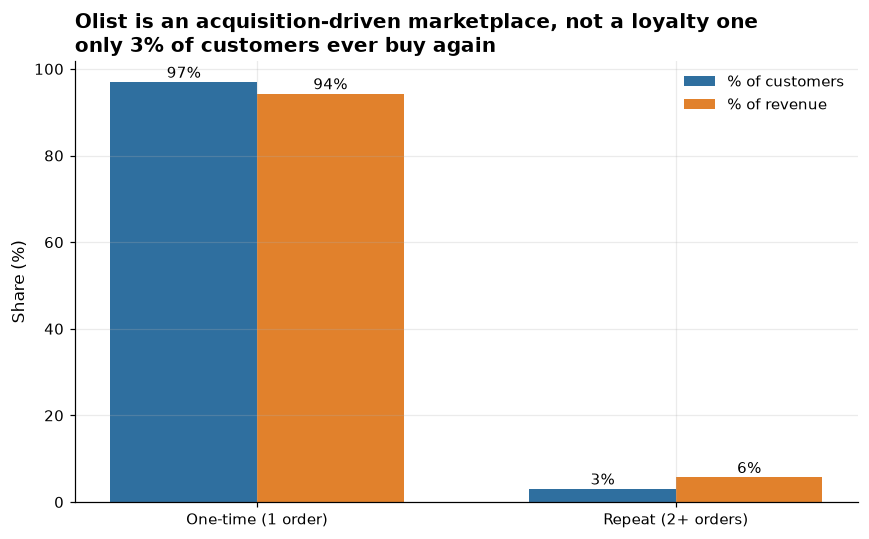

In [4]:
x = np.arange(2); w = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w/2, rfm["pct_of_customers"], w, label="% of customers", color=PALETTE[0])
ax.bar(x + w/2, rfm["pct_of_revenue"], w, label="% of revenue", color=PALETTE[1])
ax.set_xticks(x); ax.set_xticklabels(rfm["customer_type"])
ax.set_ylabel("Share (%)")
ax.set_title("Olist is an acquisition-driven marketplace, not a loyalty one\nonly 3% of customers ever buy again")
for i, (c, r) in enumerate(zip(rfm["pct_of_customers"], rfm["pct_of_revenue"])):
    ax.text(i - w/2, c + 1, f"{c:.0f}%", ha="center")
    ax.text(i + w/2, r + 1, f"{r:.0f}%", ha="center")
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "01_repeat_vs_onetime.png")
plt.show()

**Finding:** only 3.0% of customers place a second order, but they are worth nearly twice as much individually (308 BRL average lifetime value vs 161 BRL for one-time buyers). This is a normal shape for a multi-seller marketplace where the buying relationship is with the platform, not a single merchant. Most of the growth lever here is acquisition efficiency and first-purchase experience, not a loyalty programme.

## 3. Does a late delivery actually hurt the review?

In [5]:
delivery = run_sql_file(SQL / "03_delivery_vs_review.sql", engine)
delivery

,delivery_outcome,orders,avg_review_score,pct_1_or_2_star
0,Late,7661,2.57,54.0
1,On time or early,88163,4.29,9.2
2,Never delivered,8,4.50,12.5


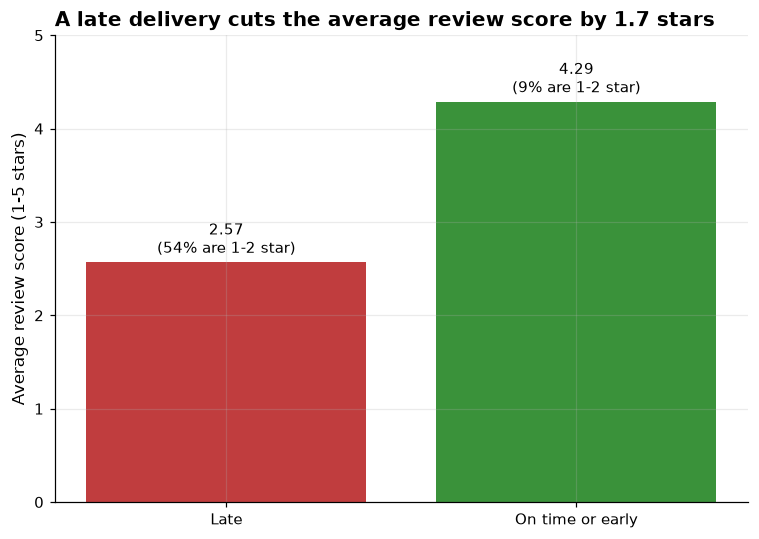

In [6]:
dv = delivery[delivery["delivery_outcome"] != "Never delivered"]
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(dv["delivery_outcome"], dv["avg_review_score"], color=[PALETTE[3], PALETTE[2]])
ax.set_ylabel("Average review score (1-5 stars)"); ax.set_ylim(0, 5)
ax.set_title("A late delivery cuts the average review score by 1.7 stars")
for bar, pct in zip(bars, dv["pct_1_or_2_star"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1, f"{bar.get_height():.2f}\n({pct:.0f}% are 1-2 star)", ha="center", fontsize=10)
fig.tight_layout()
fig.savefig(FIG / "02_delivery_vs_review.png")
plt.show()

**Finding:** yes, dramatically. Late orders average 2.57 stars with 54% landing at 1-2 stars; on-time orders average 4.29 stars with only 9% that low. "Late" is measured against Olist's own promised delivery date, not a fixed number of days, so this isolates the effect of a broken promise rather than just a slow shipment.

## 4. Where in Brazil does delivery and satisfaction break down?

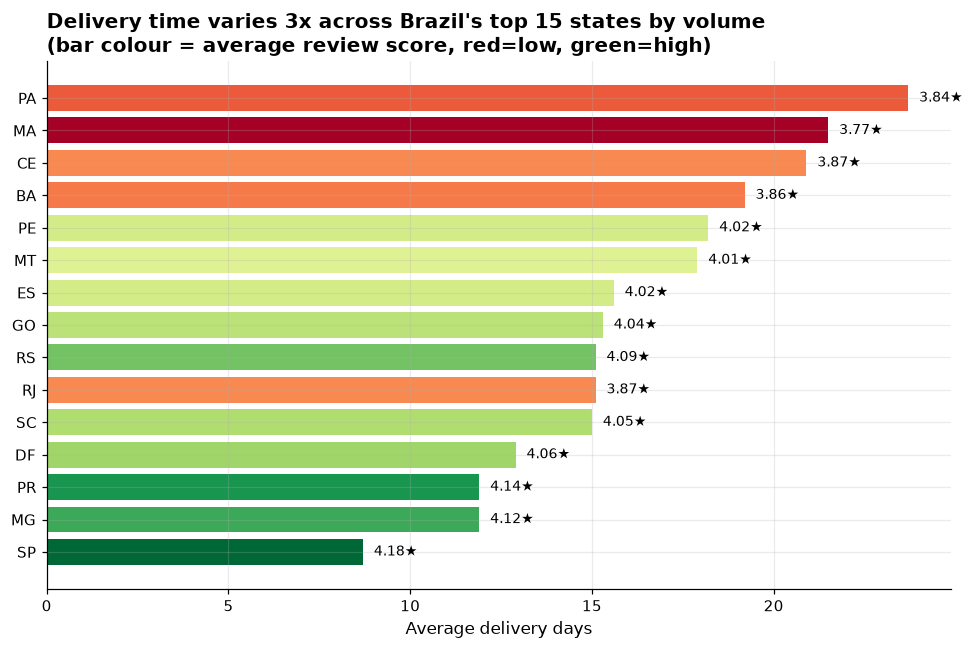

In [7]:
state = run_sql_file(SQL / "04_state_performance.sql", engine)
st = state.sort_values("orders", ascending=False).head(15).sort_values("avg_delivery_days")

fig, ax = plt.subplots(figsize=(9, 6))
norm = plt.Normalize(st["avg_review_score"].min(), st["avg_review_score"].max())
colors = plt.cm.RdYlGn(norm(st["avg_review_score"]))
ax.barh(st["customer_state"], st["avg_delivery_days"], color=colors)
ax.set_xlabel("Average delivery days")
ax.set_title("Delivery time varies 3x across Brazil's top 15 states by volume\n(bar colour = average review score, red=low, green=high)")
for y, (d, r) in enumerate(zip(st["avg_delivery_days"], st["avg_review_score"])):
    ax.text(d + 0.3, y, f"{r:.2f}\u2605", va="center", fontsize=9)
fig.tight_layout()
fig.savefig(FIG / "03_state_delivery_review.png")
plt.show()

**Finding:** Sao Paulo state (SP), Olist's home base and 42% of all orders, gets the fastest delivery (8.7 days) and the best reviews (4.18). The northern and northeastern states (PA, MA, CE, BA) see delivery times 2 to 3 times longer and reviews that sit noticeably lower. This lines up with Brazil's own geography and logistics infrastructure more than anything Olist controls directly, but it is still a real, measurable gap in the customer experience by region.

## 5. Which product categories drive revenue, and where is the quality flag?

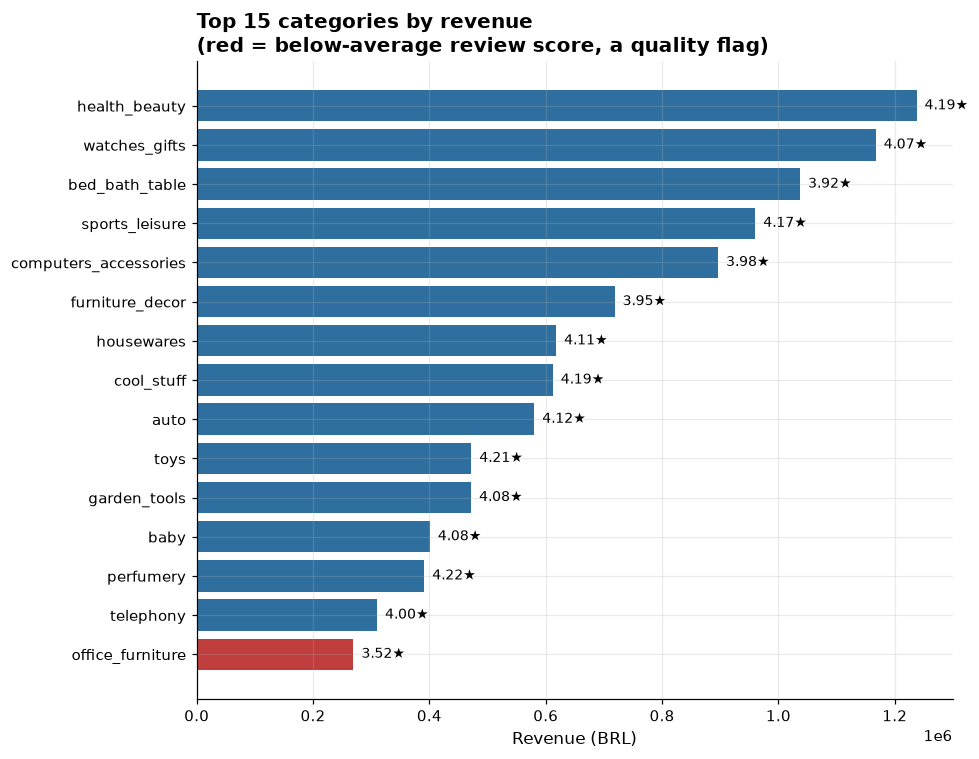

In [8]:
cat = run_sql_file(SQL / "05_category_performance.sql", engine).sort_values("revenue_brl", ascending=True)
fig, ax = plt.subplots(figsize=(9, 7))
colors = [PALETTE[3] if s < 3.8 else PALETTE[0] for s in cat["avg_review_score"]]
ax.barh(cat["category"], cat["revenue_brl"], color=colors)
ax.set_xlabel("Revenue (BRL)")
ax.set_title("Top 15 categories by revenue\n(red = below-average review score, a quality flag)")
for y, (rev, score) in enumerate(zip(cat["revenue_brl"], cat["avg_review_score"])):
    ax.text(rev, y, f"  {score:.2f}\u2605", va="center", fontsize=9)
fig.tight_layout()
fig.savefig(FIG / "04_category_revenue.png")
plt.show()

**Finding:** health & beauty leads revenue at a strong 4.19-star average. `office_furniture` stands out as the one real quality problem among the top 15: a meaningfully lower 3.52-star average, worth a direct look at return rates and product listings in that category.

## 6. What are customers actually saying? (the AI layer)

41% of reviews (40,977) include free-text comments in Portuguese. A pretrained multilingual sentiment model (`nlptown/bert-base-multilingual-uncased-sentiment`, which predicts a 1-5 star rating directly from text) was run on a stratified sample of 2,500 reviews (500 per star rating) and compared against the star rating the customer actually gave.

In [9]:
sent = pd.read_csv(PROJECT / "data/processed/review_sentiment_sample.csv")

def direction(s):
    return "Negative" if s <= 2 else ("Neutral" if s == 3 else "Positive")
sent["actual_direction"] = sent["review_score"].apply(direction)
sent["predicted_direction"] = sent["predicted_stars"].apply(direction)

order = ["Negative", "Neutral", "Positive"]
ct = pd.crosstab(sent["actual_direction"], sent["predicted_direction"], normalize="index").reindex(index=order, columns=order) * 100
agreement = (sent["actual_direction"] == sent["predicted_direction"]).mean() * 100
print(f"Direction-level agreement: {agreement:.1f}%")
ct.round(0)

Direction-level agreement: 67.8%


predicted_direction,Negative,Neutral,Positive
actual_direction,,,
Negative,86.0,8.0,6.0
Neutral,54.0,22.0,24.0
Positive,17.0,10.0,73.0


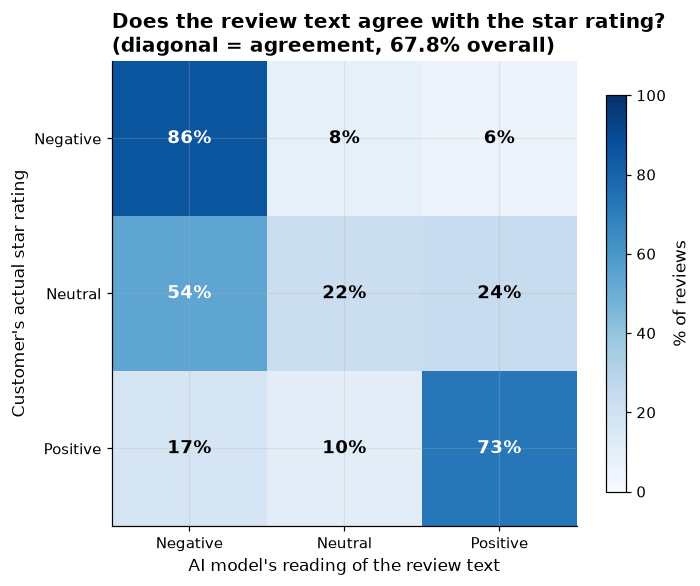

In [10]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(ct.values, cmap="Blues", vmin=0, vmax=100)
ax.set_xticks(range(3)); ax.set_xticklabels(order)
ax.set_yticks(range(3)); ax.set_yticklabels(order)
ax.set_xlabel("AI model's reading of the review text")
ax.set_ylabel("Customer's actual star rating")
ax.set_title(f"Does the review text agree with the star rating?\n(diagonal = agreement, {agreement:.1f}% overall)")
for i in range(3):
    for j in range(3):
        v = ct.values[i, j]
        ax.text(j, i, f"{v:.0f}%", ha="center", va="center", color="white" if v > 50 else "black", fontsize=12, fontweight="bold")
fig.colorbar(im, ax=ax, label="% of reviews", shrink=0.8)
fig.tight_layout()
fig.savefig(FIG / "05_sentiment_agreement.png")
plt.show()

**Finding:** the text and the star rating agree 67.8% of the time overall, and agreement is strongest for negative reviews (86%) and weakest for neutral 3-star reviews (only 22%, since a 3-star review often contains a specific complaint even when the overall rating is middling, which pulls the model toward reading it as negative).

The genuinely useful part is the disagreements. 16.9% of 4-5 star reviews contain text the model reads as negative, a real hidden-complaint signal (for example: *"A entrega foi rápida....só não foi 100% pq a cascata veio com uma mancha"*, "delivery was fast, just not 100% because the item arrived with a stain", still rated highly but flagging a real defect). Worth being honest, though: some of these are simply model errors on short or informal text, not real hidden complaints (e.g. a misspelled "ótimo produdto", "great product", scored as negative). The clearest single model failure found was a genuinely negative review, *"lannister é o pior site de compras... muito enrolado as entregas"* ("lannister is the worst shopping site, deliveries are a mess"), scored 5-star by the model. This is explainable: Olist anonymised its sellers using Game of Thrones house names, and a general-purpose sentiment model has no way to know "lannister" refers to a brand it should treat as a normal noun, not a name. That is a useful, concrete limitation to flag rather than a reason to distrust the whole exercise.

## Summary

See [`report.md`](../report.md) for the full written analysis, and [`README.md`](../README.md) for the one-page version.